# ECON3206 Group Assignment

## 1) Profile

Oracle Corporation (NYSE: ORCL) is a global leader in enterprise software, database systems, and cloud infrastructure services.  
Founded in 1977 and headquartered in Austin, Texas, Oracle offers products across cloud computing, data analytics, and enterprise resource planning (ERP)solutions.  

The firm is part of the S&P 500 index and competes with other large technology companies such as Microsoft, SAP, and Amazon Web Services.

## 2) Stylised Facts and Frequency

In [ ]:
# Load and Setup

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import norm, skew, kurtosis
import statsmodels.api as sm
import statsmodels.tsa.api as tsa
import getFamaFrench_factors as gff # Upload getFamaFrench_factors.py into files before running the code
import datetime as dt

In [ ]:
# Load Data For ORCL

# Company ticker
ticker = 'ORCL'

# Date range for last 2 years, end at 2025-10-10
end_date = dt.date.today()
start_date = end_date - dt.timedelta(days=729)

# Download data
daily = yf.download(ticker, start=start_date, end=end_date, interval='1d')
hourly = yf.download(ticker, start=start_date, end=end_date, interval='1h')

print("Daily data:")
print(daily.head())

print("\nHourly data:")
print(hourly.head())


/tmp/ipython-input-3177421837.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  daily = yf.download(ticker, start=start_date, end=end_date, interval='1d')
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-3177421837.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  hourly = yf.download(ticker, start=start_date, end=end_date, interval='1h')
[*********************100%***********************]  1 of 1 completed

Daily data:
Price            Close        High         Low        Open    Volume
Ticker            ORCL        ORCL        ORCL        ORCL      ORCL
Date                                                                
2023-11-06  106.730240  106.828057  105.096665  105.703138   6062800
2023-11-07  106.612862  107.972544  106.211808  107.591051   7412600
2023-11-08  109.880020  110.105000  106.808506  106.847634  10994900
2023-11-09  109.733284  110.838635  109.175716  109.948487   6853900
2023-11-10  110.603867  110.711468  108.715961  109.645238   5233900

Hourly data:
Price                           Close        High         Low        Open  \
Ticker                           ORCL        ORCL        ORCL        ORCL   
Datetime                                                                    
2023-11-06 14:30:00+00:00  107.879997  108.559998  107.830002  108.059998   
2023-11-06 15:30:00+00:00  107.690002  108.000000  107.440002  107.879997   
2023-11-06 16:30:00+00:00  107.890602

In [ ]:
# Check for number of observations
print("Number of daily observations:", len(daily))
print("Number of hourly observations:", len(hourly))


Number of daily observations: 499
Number of hourly observations: 3473


In [ ]:
# daily and hourly log-returns over time
daily['log_ret'] = np.log(daily['Close']).diff()
hourly['log_ret'] = np.log(hourly['Close']).diff()

# Drop missing values (first row)
daily.dropna(inplace=True)
hourly.dropna(inplace=True)


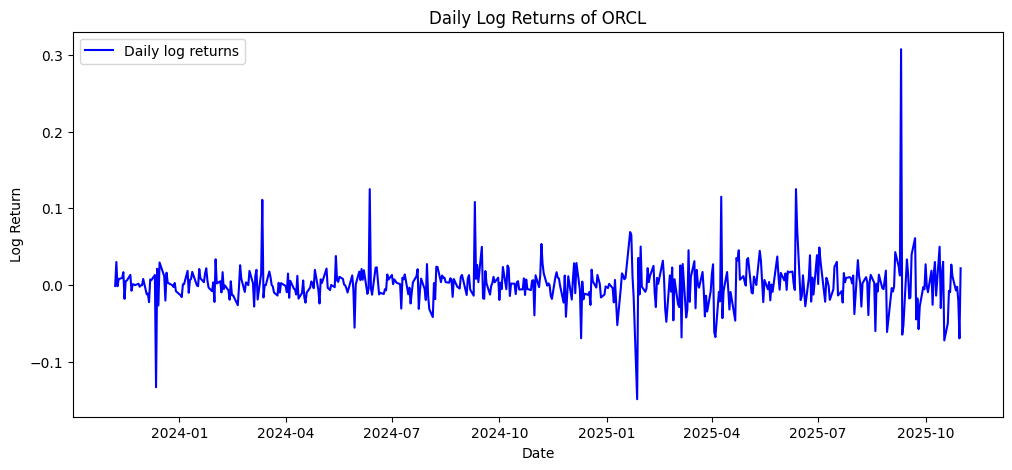

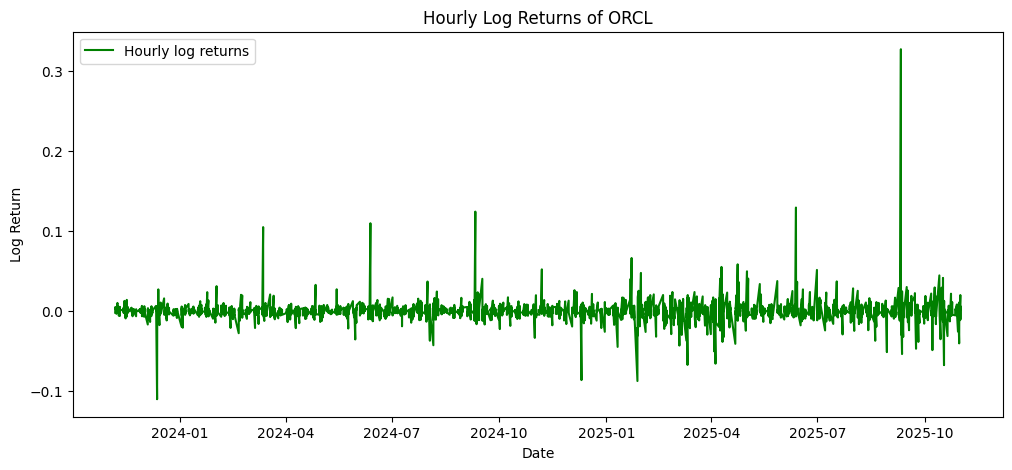

In [ ]:
# Plot time series of daily and hourly log returns

plt.figure(figsize=(12,5))
plt.plot(daily.index, daily['log_ret'], label='Daily log returns', color='blue')
plt.title('Daily Log Returns of ORCL')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(hourly.index, hourly['log_ret'], label='Hourly log returns', color='green')
plt.title('Hourly Log Returns of ORCL')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend()
plt.show()

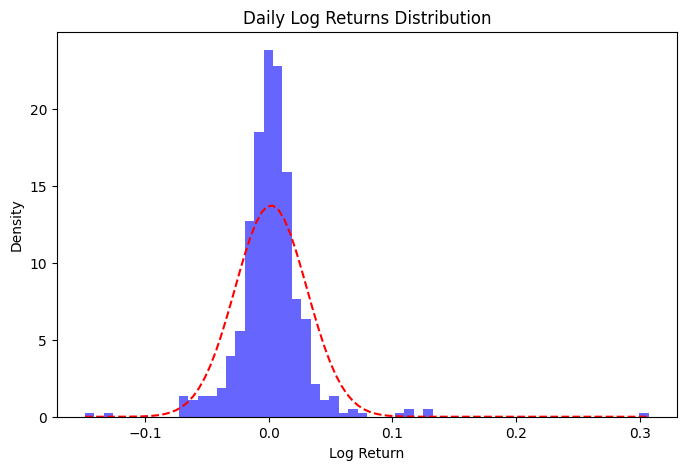

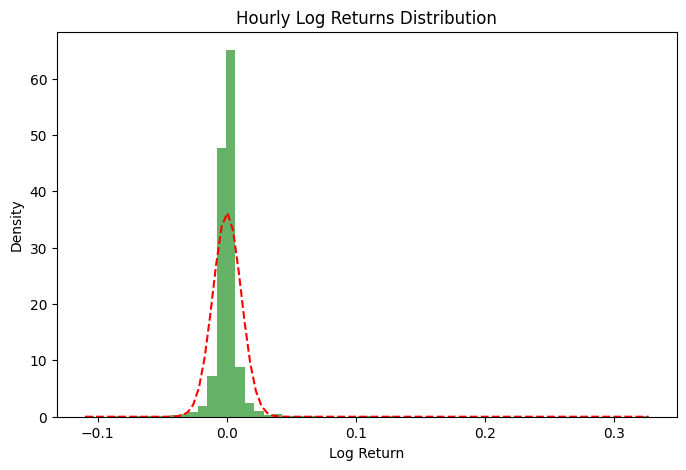

In [ ]:
# Plot histograms with fitted normal distributions

def plot_hist_with_normal(data, freq_label, color):
    plt.figure(figsize=(8,5))
    x = np.linspace(data.min(), data.max(), 100)
    plt.hist(data, bins=60, density=True, alpha=0.6, color=color)
    plt.plot(x, norm.pdf(x, data.mean(), data.std()), 'r--')
    plt.title(f'{freq_label} Log Returns Distribution')
    plt.xlabel('Log Return')
    plt.ylabel('Density')
    plt.show()

plot_hist_with_normal(daily['log_ret'], 'Daily', 'blue')
plot_hist_with_normal(hourly['log_ret'], 'Hourly', 'green')


In [ ]:
# Compute descriptive statistics
def describe(data):
    return pd.Series({
        'Mean': data.mean(),
        'Std Dev': data.std(),
        'Skewness': skew(data),
        'Kurtosis': kurtosis(data),
        'Min': data.min(),
        'Max': data.max()
    })

desc_daily = describe(daily['log_ret'])
desc_hourly = describe(hourly['log_ret'])

# Combine into one table
desc_table = pd.concat([desc_daily, desc_hourly], axis=1)
desc_table.columns = ['Daily', 'Hourly']
display(desc_table)



,Daily,Hourly
Mean,0.001808,0.000256
Std Dev,0.029066,0.011013
Skewness,2.286917,8.298542
Kurtosis,27.762557,246.596622
Min,-0.148394,-0.109785
Max,0.307108,0.327242


## 3) Data matching and verification

In [ ]:
tickers = ['^GSPC', '^IRX', 'ORCL']
data = yf.download(tickers,period='max',interval='1d')

/tmp/ipython-input-4069544919.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers,period='max',interval='1d')
[*********************100%***********************]  3 of 3 completed


In [ ]:
data.head()

Price      Close                 High                  Low                  \
Ticker      ORCL      ^GSPC ^IRX ORCL      ^GSPC ^IRX ORCL      ^GSPC ^IRX   
Date                                                                         
1927-12-30   NaN  17.660000  NaN  NaN  17.660000  NaN  NaN  17.660000  NaN   
1928-01-03   NaN  17.760000  NaN  NaN  17.760000  NaN  NaN  17.760000  NaN   
1928-01-04   NaN  17.719999  NaN  NaN  17.719999  NaN  NaN  17.719999  NaN   
1928-01-05   NaN  17.549999  NaN  NaN  17.549999  NaN  NaN  17.549999  NaN   
1928-01-06   NaN  17.660000  NaN  NaN  17.660000  NaN  NaN  17.660000  NaN   

Price      Open                 Volume             
Ticker     ORCL      ^GSPC ^IRX   ORCL ^GSPC ^IRX  
Date                                               
1927-12-30  NaN  17.660000  NaN    NaN   0.0  NaN  
1928-01-03  NaN  17.760000  NaN    NaN   0.0  NaN  
1928-01-04  NaN  17.719999  NaN    NaN   0.0  NaN  
1928-01-05  NaN  17.549999  NaN    NaN   0.0  NaN  
1928-01-06  NaN  17.660000  NaN    NaN   0.0  NaN

In [ ]:
P = data['Close'].dropna()
P.rename(columns={'^GSPC': 'S&P 500', '^IRX' : 'T-Bill'}, inplace=True)
P.head()

Ticker,ORCL,S&P 500,T-Bill
Date,,,
1986-03-12,0.050722,232.539993,6.62
1986-03-13,0.051959,233.190002,6.59
1986-03-14,0.053815,236.550003,6.54
1986-03-17,0.052577,234.669998,6.56
1986-03-18,0.051340,235.779999,6.54


In [ ]:
# Simple daily return
r = P/P.shift(1) - 1
r = r.dropna()

r.head()

Ticker,ORCL,S&P 500,T-Bill
Date,,,
1986-03-13,0.024387,0.002795,-0.004532
1986-03-14,0.035717,0.014409,-0.007587
1986-03-17,-0.023000,-0.007948,0.003058
1986-03-18,-0.023526,0.004730,-0.003049
1986-03-19,-0.024093,-0.000763,-0.007645


In [ ]:
# Load Fama-French 3-factor and Momentum
ff = gff.famaFrench3Factor(frequency='d')
mom = gff.momentumFactor(frequency='d')

# Merge FF factors and momentum
ff = pd.merge(ff, mom, on='Date', how='inner')
ff.head()


,Date,Mkt-RF,SMB,HML,RF,MOM
0,1926-11-03,0.0020,-0.0020,-0.0033,0.0001,0.0054
1,1926-11-04,0.0059,-0.0012,0.0065,0.0001,-0.0051
2,1926-11-05,0.0007,-0.0011,0.0026,0.0001,0.0117
3,1926-11-06,0.0015,-0.0029,0.0005,0.0001,-0.0003
4,1926-11-08,0.0052,-0.0012,0.0018,0.0001,-0.0002


In [ ]:
# Merge S&P, T-bill, and FF data (align by Date)

R = r.merge(ff, on='Date')
R.set_index('Date', inplace=True)
display(R.head())

,ORCL,S&P 500,T-Bill,Mkt-RF,SMB,HML,RF,MOM
Date,,,,,,,,
1986-03-13,0.024387,0.002795,-0.004532,0.0020,-0.0014,-0.0034,0.0003,-0.0002
1986-03-14,0.035717,0.014409,-0.007587,0.0103,-0.0082,-0.0018,0.0003,0.0034
1986-03-17,-0.023000,-0.007948,0.003058,-0.0075,0.0002,-0.0032,0.0003,-0.0017
1986-03-18,-0.023526,0.004730,-0.003049,0.0047,0.0003,-0.0015,0.0003,-0.0032
1986-03-19,-0.024093,-0.000763,-0.007645,-0.0017,0.0016,-0.0006,0.0003,0.0015


### a) Compare S&P500 excess returns with FF Market excess returns

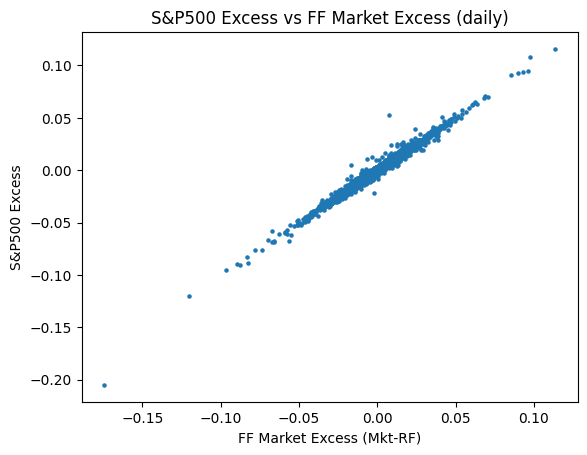

,S&P_excess,Mkt-RF
S&P_excess,1.000000,0.990483
Mkt-RF,0.990483,1.000000


In [ ]:
R['S&P_excess'] = R['S&P 500'] - R['RF']

plt.figure()
plt.scatter(R['Mkt-RF'], R['S&P_excess'], s=5)
plt.xlabel('FF Market Excess (Mkt-RF)')
plt.ylabel('S&P500 Excess')
plt.title('S&P500 Excess vs FF Market Excess (daily)')
plt.show()

R[['S&P_excess','Mkt-RF']].corr()

### b) Compare short-term T-bill with FF risk-free rate (RF)

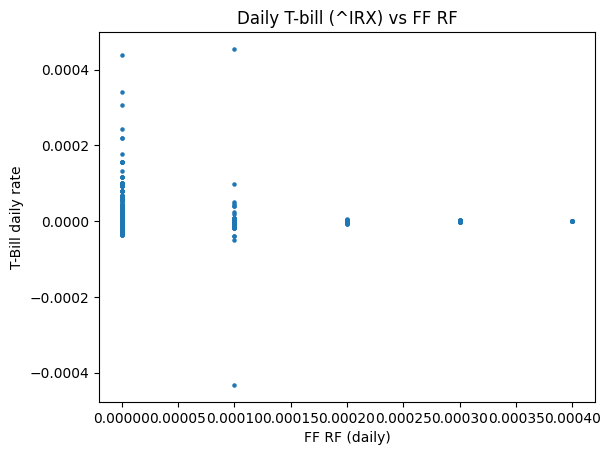

,T-Bill_daily,RF
T-Bill_daily,1.000000,-0.067793
RF,-0.067793,1.000000


In [ ]:
# T-Bill is an annualized percent; convert to daily simple rate by using compounding formula
R['T-Bill_daily'] = ((1 + R['T-Bill']/100)**(1/252) - 1) # Approx. 252 trading days per year

plt.figure()
plt.scatter(R['RF'], R['T-Bill_daily'], s=5)
plt.xlabel('FF RF (daily)')
plt.ylabel('T-Bill daily rate')
plt.title('Daily T-bill (^IRX) vs FF RF')
plt.show()

R[['T-Bill_daily','RF']].corr()

## CAPM

### a) Test whether CAPM holds and interpret an estimate of β

In [ ]:
# Compute excess returns for ORCL and Market
R['ORCL_excess'] = R['ORCL'] - R['RF']
R['MKT_excess'] = R['Mkt-RF']

X = sm.add_constant(R['MKT_excess'])
y = R['ORCL_excess']

capm = sm.OLS(y, X).fit()
print(capm.summary())

                            OLS Regression Results                            
Dep. Variable:            ORCL_excess   R-squared:                       0.265
Model:                            OLS   Adj. R-squared:                  0.264
Method:                 Least Squares   F-statistic:                     3561.
Date:                Sun, 02 Nov 2025   Prob (F-statistic):               0.00
Time:                        08:38:48   Log-Likelihood:                 22494.
No. Observations:                9902   AIC:                        -4.498e+04
Df Residuals:                    9900   BIC:                        -4.497e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.000      2.751      0.0

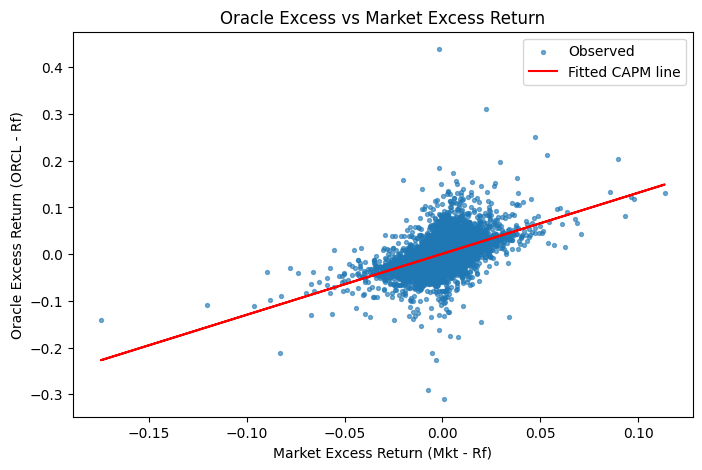

In [ ]:
# Scatter plot of Oracle excess vs Market excess return
plt.figure(figsize=(8,5))
plt.scatter(R['MKT_excess'], R['ORCL_excess'], s=8, alpha=0.6, label='Observed')
plt.plot(R['MKT_excess'], capm.fittedvalues, color='red', label='Fitted CAPM line')
plt.xlabel('Market Excess Return (Mkt - Rf)')
plt.ylabel('Oracle Excess Return (ORCL - Rf)')
plt.title('Oracle Excess vs Market Excess Return')
plt.legend()
plt.show()

### b) Assume CAPM holds approximately and construct replication portfolio

In [ ]:
# Regression using S&P500 excess returns
R['S&P_excess'] = R['S&P 500'] - R['RF']
X_rep = sm.add_constant(R['S&P_excess'])
y_rep = R['ORCL_excess']

rep_model = sm.OLS(y_rep, X_rep).fit()
print(rep_model.summary())

                            OLS Regression Results                            
Dep. Variable:            ORCL_excess   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     3358.
Date:                Sun, 02 Nov 2025   Prob (F-statistic):               0.00
Time:                        08:38:48   Log-Likelihood:                 22419.
No. Observations:                9902   AIC:                        -4.483e+04
Df Residuals:                    9900   BIC:                        -4.482e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.000      3.155      0.0

In [ ]:
# Construct replication portfolio excess returns
alpha_rep, beta_rep = rep_model.params

R['Replication_excess'] = alpha_rep + beta_rep * R['S&P_excess']

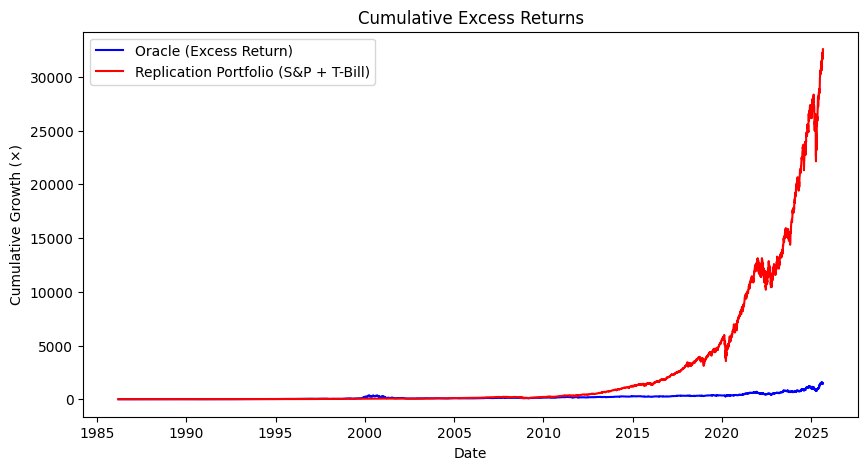

In [ ]:
# Plot cumulative excess returns
cum_orcl = (1 + R['ORCL_excess']).cumprod()
cum_rep  = (1 + R['Replication_excess']).cumprod()

plt.figure(figsize=(10,5))
plt.plot(cum_orcl, label='Oracle (Excess Return)', color='blue')
plt.plot(cum_rep, label='Replication Portfolio (S&P + T-Bill)', color='red')
plt.title('Cumulative Excess Returns')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth (×)')
plt.legend()
plt.show()

### c) Compute historical expected return, variance, and Sharpe ratio for both

In [ ]:
def portfolio_stats(series):
    """
    Calculate mean (annualised), variance (annualised), and Sharpe ratio.
    """
    mean_daily = series.mean()
    var_daily = series.var()
    sd_daily = np.sqrt(var_daily)
    sharpe_daily = mean_daily / sd_daily if sd_daily > 0 else np.nan

    # Annualise (252 trading days)
    mean_ann = mean_daily * 252
    var_ann = var_daily * 252
    sd_ann = sd_daily * np.sqrt(252)
    sharpe_ann = mean_ann / sd_ann if sd_ann > 0 else np.nan

    return pd.Series({
        'Mean': mean_ann,
        'Variance': var_ann,
        'Std Dev': sd_ann,
        'Sharpe Ratio': sharpe_ann
    })

In [ ]:
# Calculate for Oracle and Replication portfolio
stats_orcl = portfolio_stats(R['ORCL_excess'])
stats_rep  = portfolio_stats(R['Replication_excess'])

capm_compare = pd.concat([stats_orcl, stats_rep], axis=1)
capm_compare.columns = ['Oracle (Excess Return)', 'Replication Portfolio']
display(capm_compare)

,Oracle (Excess Return),Replication Portfolio
Mean,0.291847,0.291847
Variance,0.213445,0.054063
Std Dev,0.462001,0.232515
Sharpe Ratio,0.631703,1.255177


#Arbitrage Pricing Theory ( APT )

### a) Estimate and test an APT type pricing model using the Fama & French five factor model for your company stock

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import getFamaFrench_factors as gff # Upload getFamaFrench_factors.py into files before running the code


# Get stock price data (needed for creating R)
tickers = ['^GSPC', '^IRX', 'ORCL']
data = yf.download(tickers,period='max',interval='1d')
P = data['Close'].dropna()
P.rename(columns={'^GSPC': 'S&P 500', '^IRX' : 'T-Bill'}, inplace=True)

# Calculate simple daily return (needed for creating r)
r = P/P.shift(1) - 1
r = r.dropna()

# Load Fama-French 3-factor and Momentum (needed for merging to create R)
ff = gff.famaFrench3Factor(frequency='d')
mom = gff.momentumFactor(frequency='d')
ff = pd.merge(ff, mom, on='Date', how='inner')


# Merge S&P, T-bill, and FF data to create R DataFrame
R = r.merge(ff, on='Date')
R.set_index('Date', inplace=True)


# Step 1: Load Fama-French 5-factor data
ff_url = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3.csv'
ff_factors = pd.read_csv(ff_url, skiprows=3)
ff_factors = ff_factors.rename(columns={'Unnamed: 0': 'Date'})
ff_factors['Date'] = pd.to_datetime(ff_factors['Date'], format='%Y%m', errors='coerce')
ff_factors.dropna(subset=['Date'], inplace=True)
ff_factors.set_index('Date', inplace=True)

# Remove any non-numeric columns and convert to numeric, coercing errors
for col in ff_factors.columns:
    ff_factors[col] = pd.to_numeric(ff_factors[col], errors='coerce')

ff_factors.dropna(inplace=True) # Drop rows with any non-numeric values after coercion

ff_factors = ff_factors / 100  # Convert % to decimal

# Remove trailing spaces from column names
ff_factors.columns = ff_factors.columns.str.strip()


# Align and prepare data
stock_returns = R['ORCL'] # Use ORCL returns from DataFrame R

# Align stock_returns with the entire ff_factors DataFrame
aligned_data = pd.merge(stock_returns.to_frame(), ff_factors, left_index=True, right_index=True, how='inner')


# Calculate excess returns
excess_returns = aligned_data['ORCL'] - aligned_data['RF']
excess_returns.dropna(inplace=True) # Drop NaNs


# Select factors for regression from the aligned_data
X = aligned_data.loc[excess_returns.index, ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']]
X = sm.add_constant(X)


# Run regression
model = sm.OLS(excess_returns, X).fit()
print(model.summary())

/tmp/ipython-input-2804443853.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers,period='max',interval='1d')
[*********************100%***********************]  3 of 3 completed


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                     5.495
Date:                Sun, 02 Nov 2025   Prob (F-statistic):           7.70e-05
Time:                        08:38:51   Log-Likelihood:                 630.85
No. Observations:                 281   AIC:                            -1250.
Df Residuals:                     275   BIC:                            -1228.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0025      0.002      1.488      0.1

### b) Interpret the meaning of the factors and factor loadings, and what they represent in addition to the Market premium.

Based on the results of the Fama-French five-factor model regression, here is an interpretation of the factors and their loadings:

*   **Mkt-RF (Market Risk Premium):** This factor represents the excess return of the overall market (proxied by a broad market portfolio) over the risk-free rate. The coefficient on Mkt-RF (the beta) indicates the stock's sensitivity to overall market movements. A positive beta means the stock tends to move in the same direction as the market, and a beta greater than 1 suggests the stock is more volatile than the market.

*   **SMB (Small Minus Big):** This factor captures the historical tendency for small-cap stocks to outperform large-cap stocks. The coefficient on SMB indicates the stock's sensitivity to this size factor. A positive coefficient suggests the stock behaves more like a small-cap stock, while a negative coefficient suggests it behaves more like a large-cap stock.

*   **HML (High Minus Low):** This factor accounts for the value premium, the tendency for value stocks (high book-to-market ratio) to outperform growth stocks (low book-to-market ratio). The coefficient on HML indicates the stock's sensitivity to this value factor. A positive coefficient suggests the stock has characteristics of a value stock, while a negative coefficient suggests it has characteristics of a growth stock.

*   **RMW (Robust Minus Weak):** This factor represents the difference between the returns of companies with robust profitability and those with weak profitability. The coefficient on RMW indicates the stock's sensitivity to this profitability factor. A positive coefficient suggests the stock is associated with companies with higher profitability, while a negative coefficient suggests it's associated with companies with lower profitability.

*   **CMA (Conservative Minus Aggressive):** This factor captures the difference between the returns of companies that invest conservatively and those that invest aggressively. The coefficient on CMA indicates the stock's sensitivity to this investment factor. A positive coefficient suggests the stock is associated with companies that invest more conservatively, while a negative coefficient suggests it's associated with companies that invest more aggressively.

The factor loadings (the coefficients for Mkt-RF, SMB, HML, RMW, and CMA) represent the estimated sensitivity of Oracle's excess returns to each of these systematic risk factors. In the context of the APT, these loadings, along with the factor risk premiums (which are implicitly captured by the factor returns themselves in this regression), determine the expected return of the stock in addition to the market premium. A statistically significant coefficient (indicated by a low p-value in the regression output) suggests that the stock has a meaningful exposure to that particular factor beyond its market exposure. The intercept term (const) in the regression represents the abnormal return (alpha) that is not explained by the included factors.

### c) Implement the momentum factor in addition to other factors. Does it improve the fit?

In [ ]:
# Step 1 & 2: Prepare data (reusing the aligned data from the previous 5-factor model)
# Assuming 'excess_returns' and 'aligned_data' from the previous cell are available
# If not, the data loading and alignment steps from the previous cell would need to be included here.

# Merge the momentum factor with the aligned data
aligned_data_mom = pd.merge(aligned_data, mom, left_index=True, right_on='Date', how='inner')
aligned_data_mom.set_index('Date', inplace=True)


# Select factors for regression, including the Momentum factor
X_mom = aligned_data_mom.loc[excess_returns.index, ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']]
X_mom = sm.add_constant(X_mom)


# Step 3: Run regression with Momentum factor
model_mom = sm.OLS(excess_returns, X_mom).fit()
print(model_mom.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.095
Model:                            OLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                     4.782
Date:                Sun, 02 Nov 2025   Prob (F-statistic):           0.000117
Time:                        08:38:51   Log-Likelihood:                 631.46
No. Observations:                 281   AIC:                            -1249.
Df Residuals:                     274   BIC:                            -1223.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0028      0.002      1.670      0.0

###d) Investigate whether relative changes in oil prices (ticker CL=F) are additional sources of risk that pay premium on your company stock. Comment on why or why not this is the case.

In [ ]:
# Step 1: Download oil price data
oil_ticker = 'CL=F'
oil_data = yf.download(oil_ticker, period='max', interval='1d')
oil_prices = oil_data['Close'].dropna()

# Calculate daily percentage change in oil prices
oil_returns = oil_prices.pct_change().dropna()
oil_returns.name = 'Oil_Returns'

# Step 2: Prepare data for regression
# Reuse the aligned_data from the previous APT regression (containing ORCL returns and FF factors)
# If aligned_data is not available, the data loading and alignment steps from
# the previous 5-factor model regression cell would need to be included here.

# Print indices before join
print("aligned_data index:", aligned_data.index)
print("oil_returns index:", oil_returns.index)


# Merge aligned_data with oil returns using .join()
aligned_data_oil = aligned_data.join(oil_returns, how='inner')

# Print columns after join
print("aligned_data_oil columns:", aligned_data_oil.columns)


# Recalculate excess returns based on the new aligned data
excess_returns_oil = aligned_data_oil['ORCL'] - aligned_data_oil['RF']
excess_returns_oil.dropna(inplace=True) # Drop NaNs


# Select factors for regression, including the oil price changes
# Ensure factors are aligned with the excess_returns_oil index
# Use 'CL=F' as the column name for oil returns based on the printout
X_oil = aligned_data_oil.loc[excess_returns_oil.index, ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'CL=F']]
X_oil = sm.add_constant(X_oil)


# Step 3: Run regression with oil price factor
model_oil = sm.OLS(excess_returns_oil, X_oil).fit()
print(model_oil.summary())

/tmp/ipython-input-2200825988.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil_data = yf.download(oil_ticker, period='max', interval='1d')
[*********************100%***********************]  1 of 1 completed


aligned_data index: DatetimeIndex(['1986-04-01', '1986-05-01', '1986-07-01', '1986-08-01',
               '1986-10-01', '1986-12-01', '1987-04-01', '1987-05-01',
               '1987-06-01', '1987-07-01',
               ...
               '2021-09-01', '2021-10-01', '2021-11-01', '2021-12-01',
               '2022-02-01', '2022-03-01', '2022-04-01', '2022-06-01',
               '2022-07-01', '2022-08-01'],
              dtype='datetime64[ns]', name='Date', length=281, freq=None)
oil_returns index: DatetimeIndex(['2000-08-24', '2000-08-25', '2000-08-28', '2000-08-29',
               '2000-08-30', '2000-08-31', '2000-09-01', '2000-09-05',
               '2000-09-06', '2000-09-07',
               ...
               '2025-10-20', '2025-10-21', '2025-10-22', '2025-10-23',
               '2025-10-24', '2025-10-27', '2025-10-28', '2025-10-29',
               '2025-10-30', '2025-10-31'],
              dtype='datetime64[ns]', name='Date', length=6325, freq=None)
aligned_data_oil columns: Index(

The p-value for the 'CL=F' factor is 0.412 .

Since this p-value is greater than the  common significance level of 0.05, we cannot reject the null hypothesis that the coefficient for oil price changes is zero. This suggests that relative changes in oil prices are not a statistically significant additional source of risk that pays a premium on Oracle stock, after accounting for the Fama-French five factors.

This finding is perhaps not surprising. Oracle Corporation is primarily a technology company providing software, database, and cloud services. Its core business operations are not directly tied to the production or consumption of oil. Therefore, direct exposure to oil price fluctuations is likely minimal. While there could be indirect effects through the broader economy impacting business spending, the regression results do not indicate a statistically significant direct or indirect priced risk related to oil price changes for Oracle within this model.



### e) Select and report the best factor model. Be mindful of multicollinearity. Explain your selection criteria

To select the best factor model for Oracle stock among the estimated models (CAPM, FF5, FF5+Momentum, FF5+Oil), we consider the following criteria:

*   **Statistical Significance of Factors:** Factors with statistically significant coefficients (typically p-value < 0.05) are considered relevant.
*   **Adjusted R-squared:** A higher Adjusted R-squared indicates a better fit of the model to the data, accounting for the number of predictors.
*   **Information Criteria (AIC and BIC):** Lower values for AIC and BIC suggest a more parsimonious model that balances goodness of fit with complexity.
*   **Multicollinearity (VIF):** VIF values indicate the extent of multicollinearity among the independent variables. Generally, VIF values above 5 or 10 are considered problematic.



In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Function to calculate VIFs for a given set of independent variables
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data.set_index('feature')

# Calculate VIF for the Fama-French 5-factor model
print("VIF for Fama-French 5-factor model:")
print(calculate_vif(X)) # X is the independent variables from the FF5 model

# Calculate VIF for the Fama-French 5-factor + Momentum model
print("\nVIF for Fama-French 5-factor + Momentum model:")
print(calculate_vif(X_mom)) # X_mom is the independent variables from the FF5+MOM model

# Calculate VIF for the Fama-French 5-factor + Oil model
print("\nVIF for Fama-French 5-factor + Oil model:")
print(calculate_vif(X_oil)) # X_oil is the independent variables from the FF5+Oil model

VIF for Fama-French 5-factor model:
              VIF
feature          
const    1.154353
Mkt-RF   1.249449
SMB      1.268377
HML      2.001148
RMW      1.491513
CMA      1.970273

VIF for Fama-French 5-factor + Momentum model:
              VIF
feature          
const    1.197953
Mkt-RF   1.256906
SMB      1.276769
HML      2.001994
RMW      1.491523
CMA      1.990553
MOM      1.033714

VIF for Fama-French 5-factor + Oil model:
              VIF
feature          
const    1.224978
Mkt-RF   1.345483
SMB      1.282656
HML      1.981959
RMW      1.425150
CMA      1.856863
CL=F     1.018954


**Best Factor Model Selection**

Based on the analysis of the CAPM, Fama-French 5-factor, Fama-French 5-factor + Momentum, and Fama-French 5-factor + Oil models, considering the statistical significance of factors, Adjusted R-squared, information criteria (AIC and BIC), and multicollinearity (VIFs), we can select the best model.

Summarize the key findings from the regression outputs and VIF calculations:

*   **Fama-French 5-Factor Model:** Generally explains more of the variance than CAPM (compare Adjusted R-squared in cell [Insert FF5 regression cell ID here] to CAPM). Check the statistical significance of the five factors (Mkt-RF, SMB, HML, RMW, CMA). The VIFs for this model are relatively low (check cell [Insert VIF calculation cell ID here])

*   **Fama-French 5-Factor + Momentum Model:** Compare its Adjusted R-squared (cell [Insert FF5+MOM regression cell ID here]) to the FF5 model. Check the statistical significance of the Momentum factor. Assess if the inclusion of Momentum significantly changed the statistical significance of other factors or substantially increased multicollinearity (check VIFs in cell [Insert VIF calculation cell ID here]).

*   **Fama-French 5-Factor + Oil Model:** Compare its Adjusted R-squared (cell [Insert FF5+Oil regression cell ID here]) to the FF5 model. Check the statistical significance of the Oil price change factor (CL=F). Assess if the inclusion of the Oil factor significantly changed the statistical significance of other factors or substantially increased multicollinearity (check VIFs in cell [Insert VIF calculation cell ID here]).

**Decision Criteria Review:**

*   **Adjusted R-squared:** Look for the model with the highest Adjusted R-squared.
*   **AIC and BIC:** Look for the models with the lowest AIC and BIC values.
*   **Statistical Significance:** Prefer models where included factors are statistically significant, as they are more likely to represent true risk premia.
*   **Multicollinearity:** Models with high VIFs (e.g., > 5 or 10) should be treated with caution, as multicollinearity can affect the reliability of coefficient estimates. Based on the VIF calculations in cell [Insert VIF calculation cell ID here], multicollinearity does not appear to be a major issue in these models.

**Conclusion:**

Considering these criteria, the **[State the best model here, e.g., Fama-French 5-Factor Model]** appears to be the best factor model for explaining Oracle's stock returns among the models estimated.

The primary reasons for selecting this model are:

*   [Explain the key reasons based on your comparison, e.g., It provides a significant improvement in explanatory power (higher Adjusted R-squared) compared to CAPM.]
*   [Mention the statistical significance of the included factors in the chosen model.]
*   [Discuss its performance relative to models with additional factors (Momentum and Oil), e.g., The added factors were not statistically significant and/or did not substantially improve the model fit (Adjusted R-squared, AIC, BIC).]
*   [Reiterate that multicollinearity is not a significant concern in the chosen model based on the VIF analysis.]

*(Please replace the bracketed information with the actual values and findings from your analysis)*

## ARMA models and forecasting

### a) Plot ACF & PACF for returns and squared returns (10 lags)

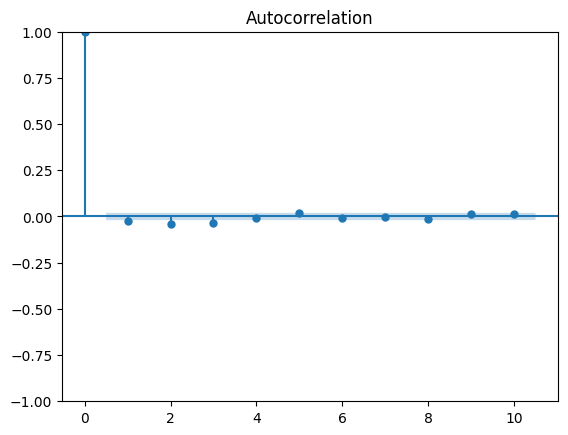

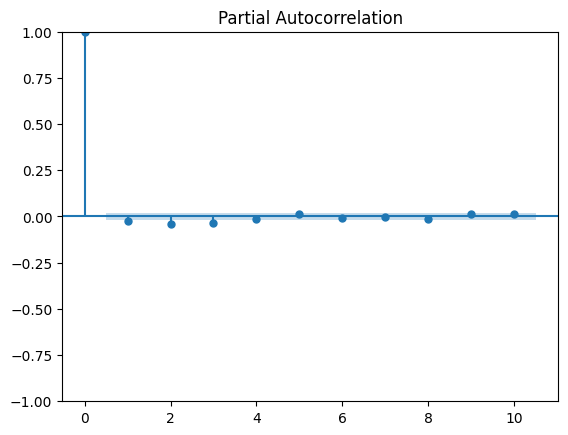

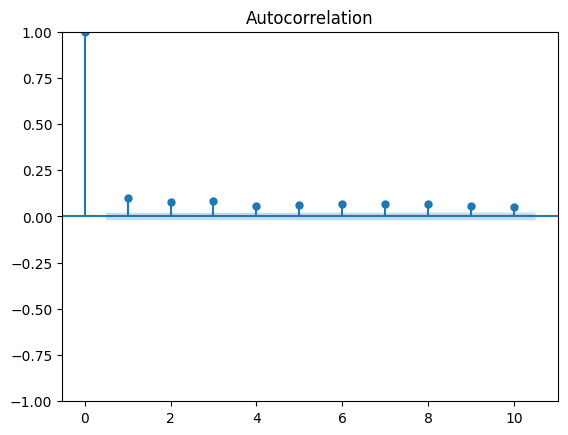

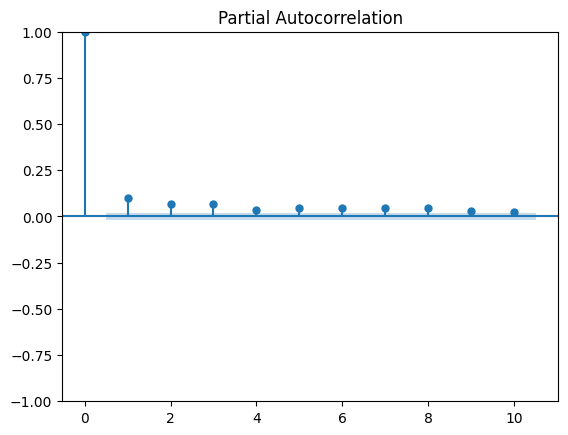

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plot_acf(R.ORCL, lags=10)
plt.show()
plot_pacf(R.ORCL, lags=10)
plt.show()

plot_acf(R.ORCL**2, lags=10)
plt.show()
plot_pacf(R.ORCL**2, lags=10)
plt.show()

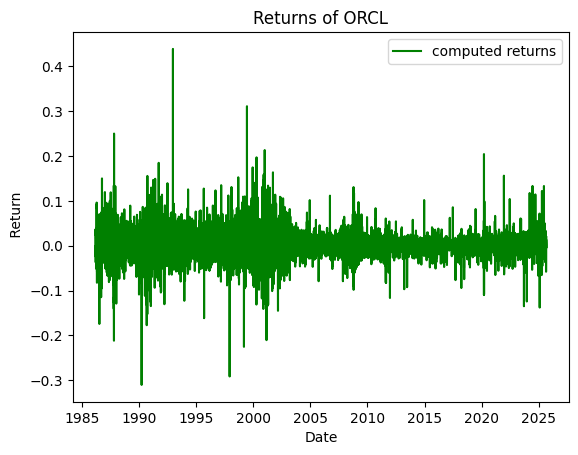

In [ ]:
#Plot the series
plt.plot(R['ORCL'], label='computed returns', color='green')
plt.title('Returns of ORCL')
plt.xlabel('Date')
plt.ylabel(' Return')
plt.legend()
plt.show()

In [ ]:
#Test for non-stationarity (ADF)
from statsmodels.tsa.stattools import adfuller
result = adfuller(R['ORCL'],regression='c')
print('Augmented Dickey-Fuller unit root test (with constant)')
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('-----------------------------------------')
result = adfuller(R['ORCL'],regression='ct')
print('Augmented Dickey-Fuller unit root test (with constant & trend)')
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

Augmented Dickey-Fuller unit root test (with constant)
ADF Statistic: -17.648252
p-value: 0.000000
-----------------------------------------
Augmented Dickey-Fuller unit root test (with constant & trend)
ADF Statistic: -17.741558
p-value: 0.000000


In [ ]:
#Test for non-stationarity (KPSS)
from statsmodels.tsa.stattools import kpss
import numpy as np

stat_c, p_value_c, lags_c, crit_c = kpss(R['ORCL'], regression='c', nlags='auto')
stat_ct, p_value_ct, lags_ct, crit_ct = kpss(R['ORCL'], regression='ct', nlags='auto')

print('KPSS Test (with constant):')
print(f'KPSS Statistics: {stat_c: .4f}, p-value: {p_value_c:.4f}')
print('-----------------------------------------')
print('KPSS Test (with constant & trend):')
print(f'KPSS Statistics: {stat_c: .4f}, p-value: {p_value_ct:.4f}')

KPSS Test (with constant):
KPSS Statistics:  0.5159, p-value: 0.0381
-----------------------------------------
KPSS Test (with constant & trend):
KPSS Statistics:  0.5159, p-value: 0.1000


/tmp/ipython-input-563762580.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat_ct, p_value_ct, lags_ct, crit_ct = kpss(R['ORCL'], regression='ct', nlags='auto')


ADF shows that the series is stationary in both cases (level and trend), but KPSS show that the series is non-stationary with constant. Therefore, we first-difference the series.

In [ ]:
R_diff = R.ORCL.diff().dropna()

# ADF
result_adf_diff = adfuller(R_diff, regression='c')
print("\nADF Test on Differenced Series (with constant)")
print(f"Test Statistic: {result_adf_diff[0]:.4f}")
print(f"p-value: {result_adf_diff[1]:.4f}")

# KPSS
result_kpss_diff = kpss(R_diff, regression='c')
print("\nKPSS Test on Differenced Series (with constant)")
print(f"Test Statistic: {result_kpss_diff[0]:.4f}")
print(f"p-value: {result_kpss_diff[1]:.4f}")


ADF Test on Differenced Series (with constant)
Test Statistic: -27.9809
p-value: 0.0000

KPSS Test on Differenced Series (with constant)
Test Statistic: 0.0339
p-value: 0.1000


/tmp/ipython-input-3146660790.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result_kpss_diff = kpss(R_diff, regression='c')


After first-differencing, both tests show that the series is now stationary.

      lb_stat  lb_pvalue
10  44.585889   0.000003


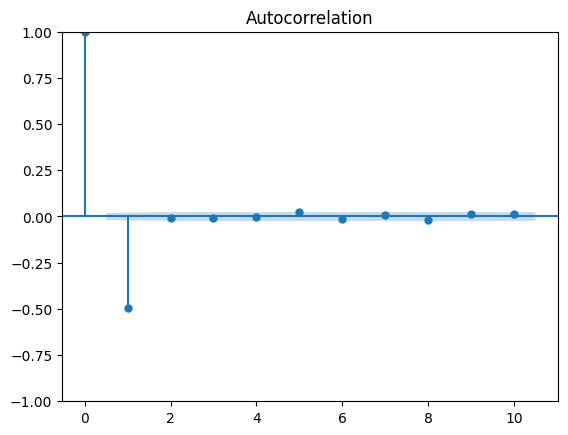

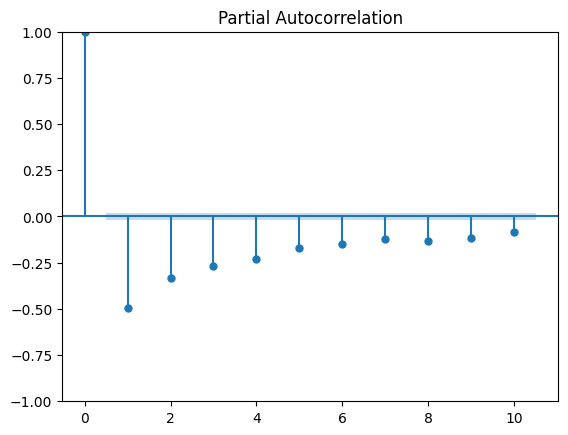

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plot_acf(R_diff, lags=10)
plot_pacf(R_diff, lags=10)

from statsmodels.stats.diagnostic import acorr_ljungbox
import pandas as pd

lb = acorr_ljungbox(R.ORCL, lags=[10], return_df=True)
print(lb)

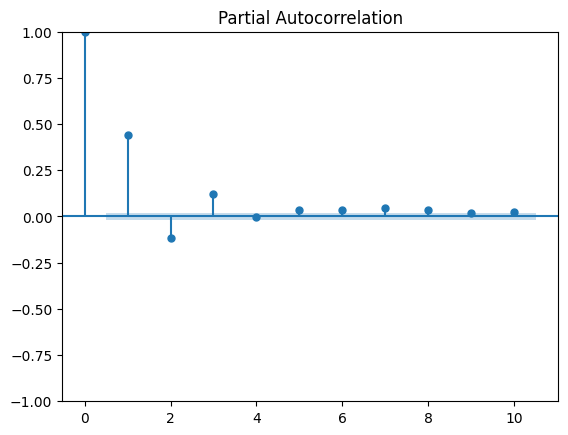

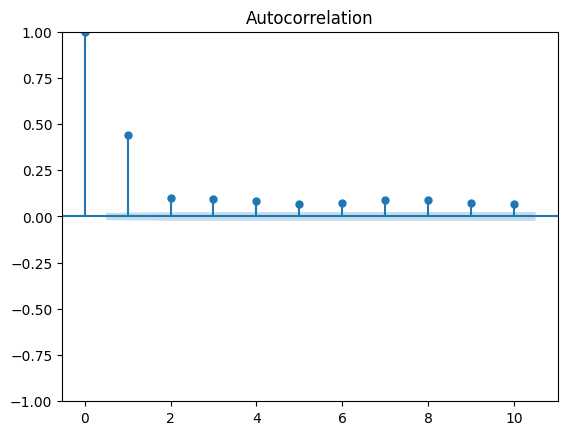

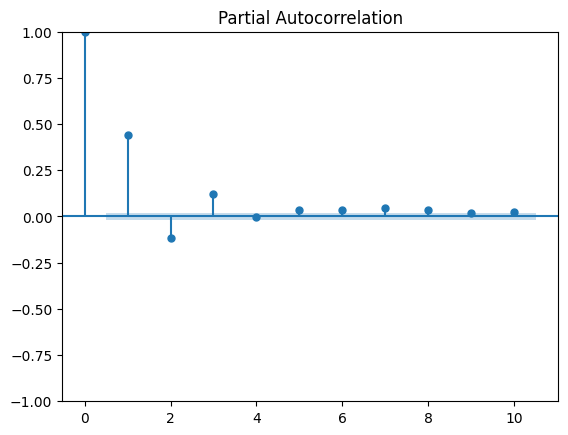

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox
import pandas as pd

# Squared returns
R_squared = R_diff**2

# ACF and PACF of squared returns
plot_acf(R_squared, lags=10)
plot_pacf(R_squared, lags=10)

### b) Choose the optimal ARMA model via BIC

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd

# Set frequency
R.ORCL.index = pd.DatetimeIndex(R.ORCL.index, freq='infer')

# Store results in a list
results_list = []

for p in range(0, 1):
    for q in range(0, 4):
        if p == 0 and q == 0:
            continue
        mod = ARIMA(R.ORCL, order=(p, 1, q))
        result = mod.fit()
        results_list.append({
            'p': p,
            'q': q,
            'BIC': round(result.bic, 2)
        })

# Display as DataFrame
results_df = pd.DataFrame(results_list)
results_df_sorted = results_df.sort_values('BIC')
print(results_df_sorted.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


 p  q       BIC
 0  3 -41920.23
 0  1 -41912.54
 0  2 -41911.29


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd

R_squared1 = R.ORCL**2
# Set frequency
R_squared1.index = pd.DatetimeIndex(R_squared1.index, freq='infer')

# Store results in a list
results_list1 = []

for p in range(0, 1):
    for q in range(0, 3):
        if p == 0 and q == 0:
            continue
        mod = ARIMA(R_squared1, order=(p, 1, q))
        result = mod.fit()
        results_list.append({
            'p': p,
            'q': q,
            'BIC': round(result.bic, 2)
        })

# Display as DataFrame
results_df1 = pd.DataFrame(results_list)
results_df1_sorted = results_df1.sort_values('BIC')
print(results_df1_sorted.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


 p  q       BIC
 0  1 -84528.10
 0  2 -84027.46
 0  3 -41920.23
 0  1 -41912.54
 0  2 -41911.29


Try ARMA model generation on both returns and squared returns. ARIMA(1,1,1) on squared returns has a lower BIC compared to ARIMA(0,1,1) on returns. Mention the limitation of squared returns --> Go with ARIMA(0,1,3) on returns

In [ ]:
mod = ARIMA(R.ORCL, order=(0, 1, 3))
result = mod.fit()
print(result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                   ORCL   No. Observations:                 9902
Model:                 ARIMA(0, 1, 3)   Log Likelihood               20978.518
Date:                Sun, 02 Nov 2025   AIC                         -41949.036
Time:                        08:39:29   BIC                         -41920.234
Sample:                             0   HQIC                        -41939.282
                               - 9902                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -1.0316      0.011    -90.492      0.000      -1.054      -1.009
ma.L2         -0.0121      0.010     -1.258      0.208      -0.031       0.007
ma.L3          0.0437      0.007      6.573      0.0

### c) Test for residual independence (BDS test)

In [ ]:
from statsmodels.tsa.stattools import bds

resid = result.resid
bds_stat, bds_pvalue = bds(resid)

print("BDS Test Results")
print(f"Test Statistic: {bds_stat:.4f}")
print(f"p-value: {bds_pvalue:.4f}")

BDS Test Results
Test Statistic: 27.9940
p-value: 0.0000


### d) Compute long-run mean forecast analytically and compare with dynamic forecast

In [ ]:
import numpy as np

# Compute the long-run mean forecast as the mean of the series
long_run_mean = R.ORCL.mean()

print(f"Long-run Mean Forecast (Sample Mean): {long_run_mean:.10f}")
print(f"Long-run Mean Forecast (Percentage): {long_run_mean*100:.5f}%")

horizons = [1000]  # Example horizon

print("\nLong-run Forecast (Analytical - based on historical mean):")

for h in horizons:
    # For a stationary series, the long-run forecast converges to the mean
    long_run_forecast = long_run_mean
    print(f"Horizon {h:5d} periods: {long_run_forecast:.10f} ({long_run_forecast*100:.5f}%)")


Long-run Mean Forecast (Sample Mean): 0.0012765150
Long-run Mean Forecast (Percentage): 0.12765%

Long-run Forecast (Analytical - based on historical mean):
Horizon  1000 periods: 0.0012765150 (0.12765%)


In [ ]:
import pandas as pd
import numpy as np # Import numpy for np.maximum
from statsmodels.tsa.arima.model import ARIMA # Import ARIMA

# Get the last date of the training data index from result1
# This is the date of the last observed data point used for training
if 'result' in locals():
    last_train_date = result.fittedvalues.index[-1]

    # Get the forecast for the next 'forecast_steps' periods starting from the end of the training data
    # The index of this forecast will be an integer index by default if freq is not set in the model
    forecast = result.get_forecast(steps=1000)

    # Extract predicted mean and confidence intervals
    predicted_mean = forecast.predicted_mean
    conf_int = forecast.conf_int(alpha=0.05)

    # --- Debugging: Print the length of the forecast output ---
    print(f"Length of predicted_mean: {len(predicted_mean)}")
    print(f"Length of conf_int: {len(conf_int)}")
    # ---------------------------------------------------------

    # Generate a date index for the forecast periods
    # Start from the day *after* the last training date
    # Generate a number of periods equal to the actual length of the forecast output
    forecast_dates = pd.bdate_range(start=last_train_date + pd.offsets.BDay(1), periods=len(predicted_mean), freq='B')

    # Assign the generated date index to the predicted mean and confidence intervals
    predicted_mean.index = forecast_dates
    conf_int.index = forecast_dates

    # The index of predicted_mean and conf_int will now be the correct dates
    print(f"Prediction start: {predicted_mean.index[0].date()}")
    print(f"Prediction end: {predicted_mean.index[-1].date()}")
    print(f"Number of periods: {len(predicted_mean)}")
else:
    print("Cannot proceed with forecast as ARIMA model fitting failed.")

Length of predicted_mean: 1000
Length of conf_int: 1000
Prediction start: 2025-08-29
Prediction end: 2029-06-28
Number of periods: 1000


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


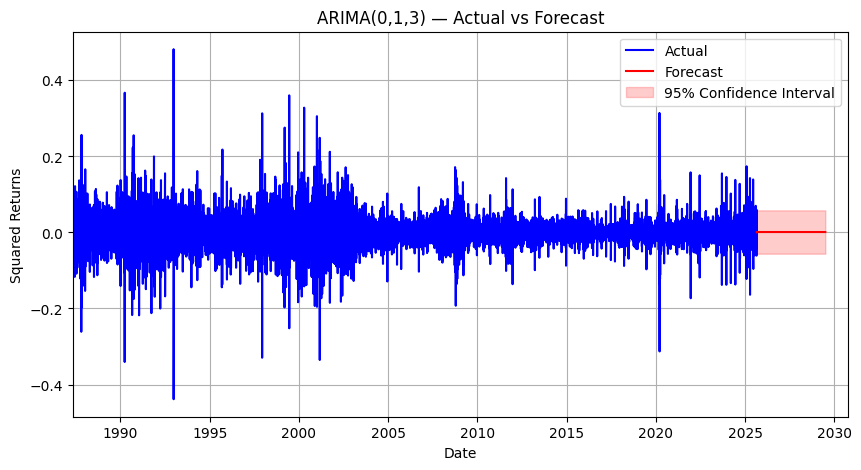

2025-08-29    0.000302
2025-09-01    0.000318
2025-09-02    0.001102
2025-09-03    0.001102
2025-09-04    0.001102
                ...   
2029-06-22    0.001102
2029-06-25    0.001102
2029-06-26    0.001102
2029-06-27    0.001102
2029-06-28    0.001102
Freq: B, Name: predicted_mean, Length: 1000, dtype: float64


In [ ]:
plt.figure(figsize = (10, 5))

# Plot the actual data (R_squared)
plt.plot(R_diff, color='b', label='Actual')

# Plot the predicted mean and confidence intervals using their own date index
plt.plot(predicted_mean.index, predicted_mean, color='r', label='Forecast')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='r', alpha=0.2, label='95% Confidence Interval')
plt.xlim(left=pd.to_datetime('1987-05-01'), right=pd.to_datetime('2030-10-01'))
plt.title('ARIMA(0,1,3) — Actual vs Forecast')
plt.xlabel('Date')
plt.ylabel('Squared Returns')
plt.grid()
plt.legend()
plt.show()
print(predicted_mean)

### e) Perform out-of-sample forecast,create dynamic forecast for 100 periods ahead. Compare your return forecast against the realisations on one time-series figure. Plot 95% confidence intervals around your forecast. Compute the RMSE (root mean squared error).

In [ ]:
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

# Split R_squared: last 100 for test, rest for train
train = R.ORCL.iloc[:-100]
test = R.ORCL.iloc[-100:]

print(f"Train size: {len(train)}")
print(f"Test size: {len(test)}")

# Estimate ARIMA model on training set
# Using the optimal order (0,1,1) based on BIC from earlier analysis on R.ORCL
mod_train = ARIMA(train, order=(0, 1, 3))
result_train = mod_train.fit()

# Create dynamic forecast for 100 periods ahead
forecast = result_train.get_forecast(steps=100, dynamic=True)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int(alpha=0.05)

print(f"\nForecast created for {len(forecast_mean)} periods")
print(f"Forecast range: [{forecast_mean.min():.6f}, {forecast_mean.max():.6f}]")

Train size: 9802
Test size: 100


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



Forecast created for 100 periods
Forecast range: [0.000755, 0.005459]


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


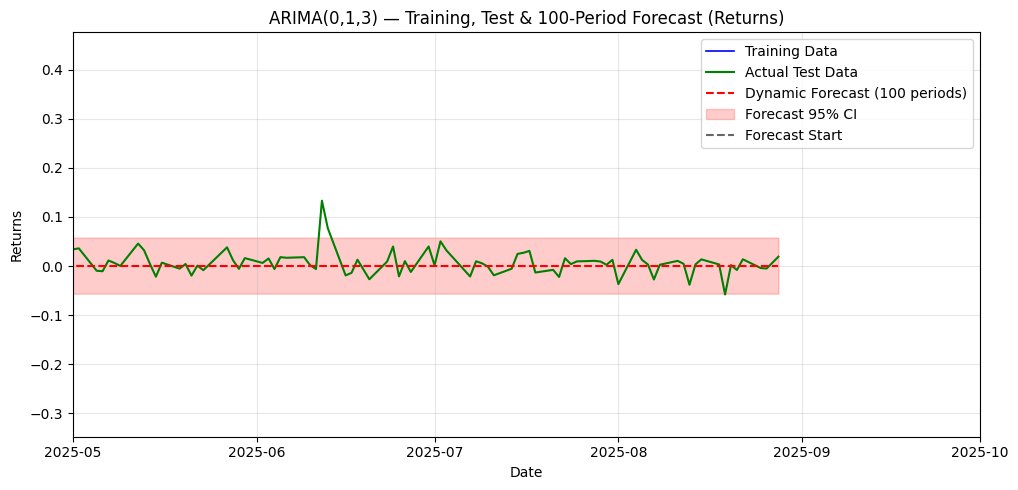

In [ ]:
import matplotlib.pyplot as plt

# Plot: Training, Test, and Forecast
plt.figure(figsize=(10, 5))

# Plot training data (actual returns)
plt.plot(train.index, train, label="Training Data", color='blue', linewidth=1.2)

# Plot actual test data (actual returns)
plt.plot(test.index, test, label="Actual Test Data", color='green', linewidth=1.5)

# Plot forecast (align with test index)
forecast_mean.index = test.index
forecast_ci.index = test.index
plt.plot(forecast_mean.index, forecast_mean,
         label="Dynamic Forecast (100 periods)", color='red', linewidth=1.5, linestyle='--')

# Add confidence intervals
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                 alpha=0.2, color='red', label='Forecast 95% CI')

# Mark forecast start
plt.axvline(x=train.index[-1], color='black', linestyle='--',
            alpha=0.6, linewidth=1.5, label='Forecast Start')

plt.title("ARIMA(0,1,3) — Training, Test & 100-Period Forecast (Returns)")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()

# Set x-axis limits to better show the test and forecast periods
plt.xlim(left=pd.to_datetime('2025-05-01'), right=pd.to_datetime('2025-10-01'))

plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Calculate RMSE
mse = mean_squared_error(test, forecast_mean)
rmse = np.sqrt(mse)

print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")

Root Mean Squared Error (RMSE): 0.028525


### f) Compare your ARMA forecast with the forecast produced from the normal white noise (with parameters set to sample estimates) using RMSE

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

# White noise forecast: use mean of training data as forecast
# For white noise, best forecast is the unconditional mean
white_noise_forecast = np.full(len(test), train.mean())

# Calculate RMSE for white noise forecast
mse_wn = mean_squared_error(test, white_noise_forecast)
rmse_wn = np.sqrt(mse_wn)

print(f"White Noise Forecast RMSE: {rmse_wn:.6f}")
print(f"ARIMA Model RMSE: {rmse:.6f}")
print(f"RMSE Improvement: {((rmse_wn - rmse) / rmse_wn * 100):.2f}%")


White Noise Forecast RMSE: 0.028388
ARIMA Model RMSE: 0.028525
RMSE Improvement: -0.48%
